<a href="https://colab.research.google.com/github/BINARYe2e2/dryou/blob/main/osaka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚠️ [주의] 'my_covid_data.csv' 파일을 찾을 수 없어 테스트용 CSV(korea_covid_1st_wave.csv)를 자동 생성합니다.
🔍 [Pure Math 가변 특이점 감지] 총 4개 추출 -> Day [6.0, 14.0, 24.0, 31.0]
🤖 [역문제 전역 최적화 실행] Differential Evolution 연산 중...

📊 [고도화된 역추정 파라미터 결과]
• 감지된 특이점 시점     : [6.0, 14.0, 24.0, 31.0]
• 초기 전파율 (beta0)     : 1.3448
• 추정된 초기 잠복기 인구 : E0 = 4.41 * I0 (136.7명)
• 잠복기 전환율 (sigma)   : 0.4996 (평균 잠복기: 2.00일)
• 평균 회복률 (gamma)     : 0.1442 (평균 격리기간: 6.93일)
  - 특이점 1 (Day 6.0) -> 방역 감쇄율(w): 70.0%, 기울기(k): 0.557
  - 특이점 2 (Day 14.0) -> 방역 감쇄율(w): 63.5%, 기울기(k): 0.382
  - 특이점 3 (Day 24.0) -> 방역 감쇄율(w): 19.6%, 기울기(k): 0.187
  - 특이점 4 (Day 31.0) -> 방역 감쇄율(w): 23.1%, 기울기(k): 0.133


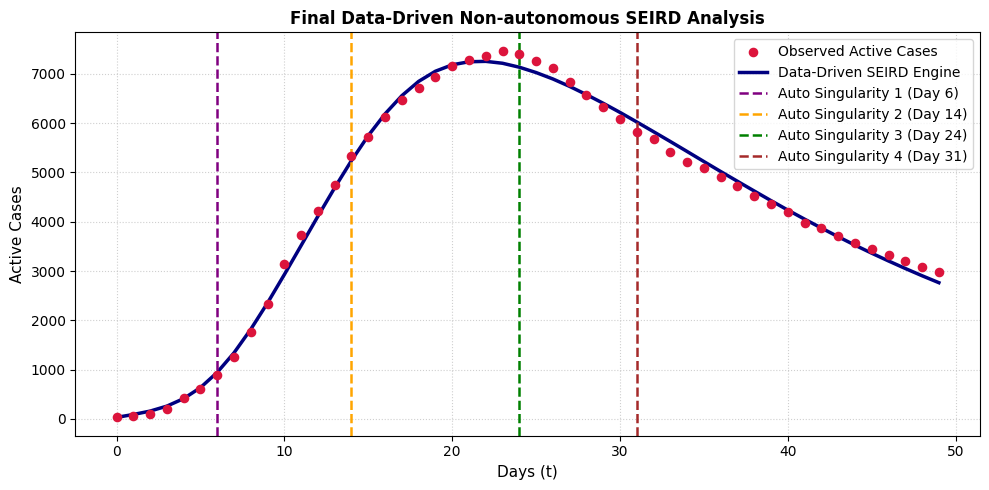

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
from scipy.signal import savgol_filter, find_peaks

# =============================================================================
# Step 0. 데이터 로드 및 예비 생성 (실제 CSV 파일 경로 지정 가능)
# =============================================================================
def get_target_csv_path(user_csv_path='my_covid_data.csv'):
    """
    1. user_csv_path에 실제 데이터 파일이 존재하면 해당 파일 경로를 그대로 사용합니다.
    2. 파일이 없을 경우, 예시용 테스트 CSV를 자동으로 생성하여 경로를 반환합니다.
    """
    if os.path.exists(user_csv_path):
        print(f"📁 [실제 데이터 로드] '{user_csv_path}' 파일을 성공적으로 불러왔습니다.")
        return user_csv_path
    else:
        print(f"⚠️ [주의] '{user_csv_path}' 파일을 찾을 수 없어 테스트용 CSV(korea_covid_1st_wave.csv)를 자동 생성합니다.")
        test_filename = 'korea_covid_1st_wave.csv'

        dates = pd.date_range(start="2020-02-18", periods=50, freq="D")
        active_cases_data = [
            31, 51, 104, 204, 433, 602, 893, 1261, 1766, 2337, 3150, 3736, 4212,
            4750, 5328, 5727, 6127, 6463, 6722, 6934, 7165, 7274, 7362, 7470, 7402,
            7254, 7120, 6838, 6577, 6325, 6085, 5823, 5684, 5418, 5220, 5084, 4899,
            4722, 4523, 4363, 4192, 3979, 3867, 3705, 3575, 3448, 3326, 3200, 3080, 2980
        ]
        recovered_data = np.int64(np.cumsum(np.linspace(0, 150, 50)))
        deaths_data = np.int64(np.cumsum(np.linspace(0, 4, 50)))
        confirmed_data = np.array(active_cases_data) + recovered_data + deaths_data

        df = pd.DataFrame({
            'date': dates.strftime('%Y-%m-%d'),
            'confirmed': confirmed_data,
            'recovered': recovered_data,
            'deaths': deaths_data,
            'active_cases': active_cases_data
        })
        df.to_csv(test_filename, index=False, encoding='utf-8-sig')
        return test_filename

# =============================================================================
# Step 1. 데이터 노이즈 스무딩 및 N개 가변 특이점(Singularities) 추출
# =============================================================================
def extract_variable_singularities(I_obs, min_distance=7):
    """
    Savitzky-Golay 스무딩 필터 적용 후 2차 수치 차분(곡률) 및 Peak Detection을 통해
    데이터 기반의 N개 가변 특이점을 자동 감지합니다.
    """
    # 1. 노이즈 제거 (Savitzky-Golay 스무딩)
    window_length = min(11, len(I_obs) if len(I_obs) % 2 != 0 else len(I_obs) - 1)
    if window_length >= 5:
        I_smooth = savgol_filter(I_obs, window_length=window_length, polyorder=2)
    else:
        I_smooth = I_obs

    # 2. 2차 수치 차분 (가속도/곡률)
    diff1 = np.diff(I_smooth)
    diff2 = np.abs(np.diff(diff1))

    # 3. 곡률의 극대점(Peak) 자동 감지
    prominence_threshold = np.max(diff2) * 0.15 if len(diff2) > 0 else 0
    peaks, _ = find_peaks(diff2, distance=min_distance, prominence=prominence_threshold)

    singularities = (peaks + 1).astype(float).tolist()

    # 예외 처리: 감지된 특이점이 없을 경우 곡률 최대 지점 1개 선정
    if len(singularities) == 0:
        singularities = [float(np.argmax(diff2) + 1)]

    print(f"🔍 [Pure Math 가변 특이점 감지] 총 {len(singularities)}개 추출 -> Day {singularities}")
    return singularities

# =============================================================================
# Step 2. 데이터 전처리
# =============================================================================
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)

    # 활성 감염자 수(I_obs) 컬럼 유연 처리
    if 'active_cases' in df.columns:
        I_obs = df['active_cases'].values.astype(float)
    elif 'active' in df.columns:
        I_obs = df['active'].values.astype(float)
    elif '현재격리자' in df.columns:
        I_obs = df['현재격리자'].values.astype(float)
    else:
        I_obs = (df['confirmed'] - df['recovered'] - df['deaths']).values.astype(float)

    R_obs = df['recovered'].values.astype(float) if 'recovered' in df.columns else np.zeros_like(I_obs)
    D_obs = df['deaths'].values.astype(float) if 'deaths' in df.columns else np.zeros_like(I_obs)

    days = len(I_obs)
    t_eval = np.arange(0, days, 1)
    N = 50_000_000  # 대한민국 기준 전체 인구수

    return df, t_eval, I_obs, R_obs, D_obs, N

# =============================================================================
# Step 3. N개 특이점 주입형 일반화 비자율 SEIRD 미분방정식계
# =============================================================================
def generalized_non_autonomous_seird(t, y, beta0, weights, ks, singularities, sigma, gamma0, mu, N):
    S, E, I, R, D = y

    # N개 특이점에 대한 곱쇄형(Multiplicative Decay) 연속 전파율 계산
    decay_factor = 1.0
    for t_sp, w, k in zip(singularities, weights, ks):
        decay = w / (1.0 + np.exp(-k * (t - t_sp)))
        decay_factor *= (1.0 - decay)

    beta_t = max(beta0 * decay_factor, 0.001)

    dSdt = -beta_t * S * I / N
    dEdt = (beta_t * S * I / N) - (sigma * E)
    dIdt = (sigma * E) - (gamma0 * I) - (mu * I)
    dRdt = gamma0 * I
    dDdt = mu * I

    return [dSdt, dEdt, dIdt, dRdt, dDdt]

# =============================================================================
# Step 4. 역문제 최적화 및 결과 도출 엔진
# =============================================================================
def run_advanced_seird_engine(csv_path):
    df, t_eval, I_obs, R_obs, D_obs, N = load_and_preprocess_data(csv_path)

    # 1. 가변 특이점 자동 추출
    singularities = extract_variable_singularities(I_obs)
    num_sp = len(singularities)

    # 2. 역문제 손실함수 (MSE) 정의
    def loss_function(params):
        beta0 = params[0]
        weights = params[1 : 1 + num_sp]
        ks = params[1 + num_sp : 1 + 2 * num_sp]
        sigma, gamma0, mu, E0_factor = params[1 + 2 * num_sp :]

        # 초기 상태 변수 정립 (E0 최적화)
        I0 = I_obs[0]
        R0 = R_obs[0]
        D0 = D_obs[0]
        E0 = I0 * E0_factor
        S0 = N - (E0 + I0 + R0 + D0)
        y0 = [S0, E0, I0, R0, D0]

        sol = solve_ivp(
            generalized_non_autonomous_seird,
            (0, len(t_eval) - 1),
            y0,
            args=(beta0, weights, ks, singularities, sigma, gamma0, mu, N),
            t_eval=t_eval,
            method='RK45'
        )

        if not sol.success:
            return 1e12

        I_pred = sol.y[2]
        return np.mean((I_obs - I_pred) ** 2)

    # 3. 동적 파라미터 탐색 범위(Bounds) 설정
    bounds = [(0.1, 1.5)]  # beta0

    # 각 특이점당 감쇄 비율(w)과 기울기(k) 추가
    for _ in range(num_sp):
        bounds.append((0.05, 0.7)) # w (감쇄 비율)
        bounds.append((0.01, 0.8)) # k (전환 기울기)

    bounds.extend([
        (0.05, 0.5),    # sigma (잠복기 전환율)
        (0.01, 0.3),    # gamma0 (회복률)
        (0.0001, 0.01), # mu (치명률)
        (0.5, 5.0)      # E0_factor (초기 잠복기 비율)
    ])

    print("🤖 [역문제 전역 최적화 실행] Differential Evolution 연산 중...")
    result = differential_evolution(loss_function, bounds, maxiter=120, popsize=18, seed=42)

    # 4. 최적 파라미터 해독 및 수치 적분
    opt_params = result.x
    beta0 = opt_params[0]
    weights = opt_params[1 : 1 + num_sp]
    ks = opt_params[1 + num_sp : 1 + 2 * num_sp]
    sigma, gamma0, mu, E0_factor = opt_params[1 + 2 * num_sp :]

    I0, R0, D0 = I_obs[0], R_obs[0], D_obs[0]
    E0 = I0 * E0_factor
    y0_opt = [N - (E0 + I0 + R0 + D0), E0, I0, R0, D0]

    sol_opt = solve_ivp(
        generalized_non_autonomous_seird,
        (0, len(t_eval) - 1),
        y0_opt,
        args=(beta0, weights, ks, singularities, sigma, gamma0, mu, N),
        t_eval=t_eval,
        method='RK45'
    )

    # 5. 결과 콘솔 출력
    print("\n" + "="*60)
    print("📊 [고도화된 역추정 파라미터 결과]")
    print("="*60)
    print(f"• 감지된 특이점 시점     : {singularities}")
    print(f"• 초기 전파율 (beta0)     : {beta0:.4f}")
    print(f"• 추정된 초기 잠복기 인구 : E0 = {E0_factor:.2f} * I0 ({E0:.1f}명)")
    print(f"• 잠복기 전환율 (sigma)   : {sigma:.4f} (평균 잠복기: {1/sigma:.2f}일)")
    print(f"• 평균 회복률 (gamma)     : {gamma0:.4f} (평균 격리기간: {1/gamma0:.2f}일)")
    for i, (t_sp, w, k) in enumerate(zip(singularities, weights, ks)):
        print(f"  - 특이점 {i+1} (Day {t_sp:.1f}) -> 방역 감쇄율(w): {w*100:.1f}%, 기울기(k): {k:.3f}")
    print("="*60)

    # 6. 시각화 그래프
    plt.figure(figsize=(10, 5))
    plt.scatter(t_eval, I_obs, color='crimson', label='Observed Active Cases', s=35, zorder=3)
    plt.plot(sol_opt.t, sol_opt.y[2], color='navy', linewidth=2.5, label='Data-Driven SEIRD Engine')

    colors = ['purple', 'orange', 'green', 'brown', 'magenta']
    for idx, t_sp in enumerate(singularities):
        c = colors[idx % len(colors)]
        plt.axvline(x=t_sp, color=c, linestyle='--', linewidth=1.8,
                    label=f'Auto Singularity {idx+1} (Day {t_sp:.0f})')

    plt.title('Final Data-Driven Non-autonomous SEIRD Analysis', fontsize=12, fontweight='bold')
    plt.xlabel('Days (t)', fontsize=11)
    plt.ylabel('Active Cases', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# =============================================================================
# 메인 실행부
# =============================================================================
if __name__ == "__main__":
    # 나중에 본인의 실제 CSV 파일 경로(예: 'my_covid_data.csv')를 집어넣으시면 됩니다.
    target_file = get_target_csv_path('my_covid_data.csv')
    run_advanced_seird_engine(target_file)